In [17]:
import pandas as pd
import numpy as np
import re

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem.porter import PorterStemmer
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt


In [3]:
pd.options.display.max_rows = 100
pd.options.display.max_columns = 100
pd.set_option('display.float_format', '{:.2f}'.format)


# Import

In [4]:
sample_submission = pd.read_csv("../data/01_raw/sample_submission.csv")
raw_train = pd.read_csv("../data/01_raw/train.csv", parse_dates= ['DateTimeOfAccident', 'DateReported' ])
raw_test = pd.read_csv("../data/01_raw/test.csv", parse_dates= ['DateTimeOfAccident', 'DateReported' ])


df = raw_train.copy()


In [33]:
raw_test.info()


<class 'pandas.DataFrame'>
RangeIndex: 36000 entries, 0 to 35999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   ClaimNumber                36000 non-null  str                
 1   DateTimeOfAccident         36000 non-null  datetime64[us, UTC]
 2   DateReported               36000 non-null  datetime64[us, UTC]
 3   Age                        36000 non-null  int64              
 4   Gender                     36000 non-null  str                
 5   MaritalStatus              35982 non-null  str                
 6   DependentChildren          36000 non-null  int64              
 7   DependentsOther            36000 non-null  int64              
 8   WeeklyWages                36000 non-null  float64            
 9   PartTimeFullTime           36000 non-null  str                
 10  HoursWorkedPerWeek         36000 non-null  float64            
 11  DaysWorkedPer

In [34]:
35982 - 36000


-18

In [5]:
print(raw_train.shape, raw_test.shape)


(54000, 15) (36000, 14)


In [6]:
sample_submission


,ClaimNumber,UltimateIncurredClaimCost
0,WC8145235,3226.60
1,WC2005111,427.89
2,WC6899143,548.29
3,WC5502023,992.00
4,WC4785156,18069.46
...,...,...
35995,WC9666858,3133.24
35996,WC4800526,511.53
35997,WC3360567,428.21
35998,WC7491778,5540.64


In [10]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 54000 entries, 0 to 53999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   ClaimNumber                54000 non-null  str                
 1   DateTimeOfAccident         54000 non-null  datetime64[us, UTC]
 2   DateReported               54000 non-null  datetime64[us, UTC]
 3   Age                        54000 non-null  int64              
 4   Gender                     54000 non-null  str                
 5   MaritalStatus              53971 non-null  str                
 6   DependentChildren          54000 non-null  int64              
 7   DependentsOther            54000 non-null  int64              
 8   WeeklyWages                54000 non-null  float64            
 9   PartTimeFullTime           54000 non-null  str                
 10  HoursWorkedPerWeek         54000 non-null  float64            
 11  DaysWorkedPer

# Check

In [5]:
# check submission format
sample_submission.head()


,ClaimNumber,UltimateIncurredClaimCost
0,WC8145235,3226.60
1,WC2005111,427.89
2,WC6899143,548.29
3,WC5502023,992.00
4,WC4785156,18069.46


In [6]:
# check is claimnumber unique
df.ClaimNumber.is_unique


True

In [7]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 54000 entries, 0 to 53999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   ClaimNumber                54000 non-null  str                
 1   DateTimeOfAccident         54000 non-null  datetime64[us, UTC]
 2   DateReported               54000 non-null  datetime64[us, UTC]
 3   Age                        54000 non-null  int64              
 4   Gender                     54000 non-null  str                
 5   MaritalStatus              53971 non-null  str                
 6   DependentChildren          54000 non-null  int64              
 7   DependentsOther            54000 non-null  int64              
 8   WeeklyWages                54000 non-null  float64            
 9   PartTimeFullTime           54000 non-null  str                
 10  HoursWorkedPerWeek         54000 non-null  float64            
 11  DaysWorkedPer

# Target column

In [8]:
df['UltimateIncurredClaimCost'].describe()


count     54000.00
mean      11003.37
std       33390.99
min         121.89
25%         926.34
50%        3371.24
75%        8197.25
max     4027135.94
Name: UltimateIncurredClaimCost, dtype: float64

In [9]:
df['UltimateIncurredClaimCost'].describe()


count     54000.00
mean      11003.37
std       33390.99
min         121.89
25%         926.34
50%        3371.24
75%        8197.25
max     4027135.94
Name: UltimateIncurredClaimCost, dtype: float64

In [10]:
df = df[df['UltimateIncurredClaimCost']<400000]


In [11]:
df[df['UltimateIncurredClaimCost']>400000].sort_values("UltimateIncurredClaimCost",ascending=False).shape


(0, 15)

In [31]:
df.columns


Index(['ClaimNumber', 'DateTimeOfAccident', 'DateReported', 'Age', 'Gender',
       'MaritalStatus', 'DependentChildren', 'DependentsOther', 'WeeklyWages',
       'PartTimeFullTime', 'HoursWorkedPerWeek', 'DaysWorkedPerWeek',
       'ClaimDescription', 'InitialIncurredCalimsCost',
       'UltimateIncurredClaimCost', 'log_UltimateIncurredClaimCost'],
      dtype='str')

In [30]:
df["UltimateIncurredClaimCost"].describe()


count     54000.00
mean      11003.37
std       33390.99
min         121.89
25%         926.34
50%        3371.24
75%        8197.25
max     4027135.94
Name: UltimateIncurredClaimCost, dtype: float64

In [12]:
import plotly.express as px

fig = px.violin(df, y="UltimateIncurredClaimCost")
fig.show()


The target column is highly positive skewed (right skew), with some very large UltimateIncurredClaimCost extreme values.

In [12]:
y = df["UltimateIncurredClaimCost"]

y_log_transformed = np.log1p(y)


In [ ]:
df["log_UltimateIncurredClaimCost"] = np.log1p(df["UltimateIncurredClaimCost"])


In [ ]:
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "browser"

fig = px.violin(df, y="log_UltimateIncurredClaimCost")
fig.show()


In [ ]:
uv pip 


# Feature engineering

## Impute missing values

In [13]:
df['MaritalStatus'].value_counts(dropna=False)


MaritalStatus
S      26150
M      22500
U       5291
NaN       29
Name: count, dtype: int64

In [14]:
# There is not enough data (29) to assign missing values to a group by analysing UltimateIncurredClaimCost value (mean or median...) in each group
# let's just assign missing values to U (Unknown status)

#Replacing nan with U

df['MaritalStatus']=df['MaritalStatus'].fillna('U')


In [13]:
29/54000*100


0.053703703703703705

In [ ]:

# DELET
def DropLargeOutliers(multiplier=multiplier):

    class _DropLargeOutliers(BaseEstimator, TransformerMixin):
        def __init__(self, multiplier):
            self.multiplier = multiplier

        def fit(self, X, y):
            y = pd.Series(y)
            q1 = y.quantile(0.25)
            q3 = y.quantile(0.75)
            self.upper_ = q3 + self.multiplier * (q3 - q1)
            self.mask_ = y <= self.upper_
            return self

        def transform(self, X):
            X = pd.DataFrame(X).iloc[self.mask_.values].copy()
            return X

    return _DropLargeOutliers(multiplier)


## Create new features

In [34]:
# Datetime features
df['accident_report_delay'] = df['DateReported'] - df['DateTimeOfAccident']
df['accident_report_delay_hours'] = df['accident_report_delay'].dt.total_seconds() / 3600
df = df.drop(columns=["accident_report_delay"])

df['accident_year'] = df['DateTimeOfAccident'].dt.year
df['accident_month'] = df['DateTimeOfAccident'].dt.month
df['accident_day'] = df['DateTimeOfAccident'].dt.day
df['accident_hour'] = df['DateTimeOfAccident'].dt.hour

df['reported_year'] = df['DateReported'].dt.year
df['reported_month'] = df['DateReported'].dt.month
df['reported_year'] = df['DateReported'].dt.day

# Claim description word count
df["ClaimDescription_word_count"] = df['ClaimDescription'].apply(lambda x:len(str(x).split()))


/var/folders/9_/0xq5zfds011_vcyrr2dpt5w80000gn/T/ipykernel_47401/2359239903.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['accident_report_delay'] = df['DateReported'] - df['DateTimeOfAccident']


## Text analysis

In [16]:
df['ClaimDescription'].nunique()


28101

### Basic text cleaning

In [17]:
# Clean claim description 

stops=stopwords.words('english')
stemmer=PorterStemmer()
lemmatizer = WordNetLemmatizer()

def clean_text(text,stops=stops, stemmer=stemmer):

    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9 ]', ' ', text) 
    text = re.sub(r'\s+', ' ', text)
    
    text = text.split()
    text =[w for w in text if w not in stops] # Remove stopwords
    text = [stemmer.stem(w) for w in text] # Stemming
 #   text = [lemmatizer.lemmatize(w) for w in text]

    return text


In [18]:
df["ClaimDescription_clean"] = df["ClaimDescription"] .apply(lambda x:' '.join(clean_text(x)))


### Create kmeans clusters

In [19]:

tfidf_vec = TfidfVectorizer(ngram_range=(1,3), min_df=10)
ClaimDescription_tfidf = tfidf_vec.fit_transform(df["ClaimDescription"])

count_vec = CountVectorizer(ngram_range=(1,3),min_df=10)
ClaimDescription_count = count_vec.fit_transform(df["ClaimDescription"])


kmeans = KMeans(n_clusters=30, random_state=42)
df["ClaimDescription_tfidf_cluster"] = kmeans.fit_predict(ClaimDescription_tfidf)
df["ClaimDescription_count_cluster"] = kmeans.fit_predict(ClaimDescription_count)


In [20]:
df[df["ClaimDescription_tfidf_cluster"]==0]["ClaimDescription"].head()


33     PUSHING SKIP BIN STRAIN LOWER BACK STRAIN SOFT...
35                       WALKING SOFT TISSUE INJURY BACK
81         STRUCK ROLLER SHUTTER SOFT TISSUE INJURY NECK
105      REPETITIVE WORK SOFT TISSUE INJURY LEFT FOREARM
120    SLIPPED AND FELL INTO OTHER BOX SOFT TISSUE IN...
Name: ClaimDescription, dtype: str

In [21]:
df.groupby(df["ClaimDescription_tfidf_cluster"])["UltimateIncurredClaimCost"].agg(['mean','median','min','max','count']).sort_values("median").head()


,mean,median,min,max,count
ClaimDescription_tfidf_cluster,,,,,
26,984.81,391.95,123.16,113595.80,1097
18,1823.12,465.51,121.89,137743.29,1995
6,2837.03,547.80,143.68,358905.55,1178
8,3586.22,733.77,140.57,188093.46,2245
16,3603.28,807.78,142.51,169842.69,1928


### Most frequent words 

body_part_words = ["back","finger","hand","shoulder","eye","knee","bodi","wrist","thumb","neck","ankl","arm","index","foot","leg","elbow","forearm","tendon","muscl","head",'tissu','']
injury_type_words = ['lacer','bruis''sprain','fractur','caught','pain','burn','strain','struck','cut','hit','lift','slip','fell','twist','fall','grind','crush']
accident_object_words = ['foreign','knife','metal','steel','soft','floor','box','vehicl','stair','accid','truck','motor','ladder']

In [22]:
claims_tokens = word_tokenize(df["ClaimDescription_clean"].str.cat(sep=" "))

unigram_freq_dict = nltk.FreqDist(nltk.ngrams(claims_tokens, 1))
bigram_freq_dict = nltk.FreqDist(nltk.ngrams(claims_tokens, 2))
trigram_freq_dict = nltk.FreqDist(nltk.ngrams(claims_tokens, 3))

unigram_top_list = [word for (word,), _ in unigram_freq_dict.most_common(60)]
bigram_top_list = [" ".join(bigram) for bigram, _ in bigram_freq_dict.most_common(40)]
trigram_top_list = [" ".join(trigram) for trigram, _ in trigram_freq_dict.most_common(20)]

def contains_word(text, word):
    word_count = 0
    if word in text:
        word_count+=1
    return word_count


for w in unigram_top_list:
    df[f"CD_{w}"] = df["ClaimDescription_clean"].apply(lambda x: contains_word(x, w))

for w in bigram_top_list:
    df[f"CD_{w}"] = df["ClaimDescription_clean"].apply(lambda x: contains_word(x, w))

for w in trigram_top_list:
    df[f"CD_{w}"] = df["ClaimDescription_clean"].apply(lambda x: contains_word(x, w))


/var/folders/9_/0xq5zfds011_vcyrr2dpt5w80000gn/T/ipykernel_47401/1381097529.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"CD_{w}"] = df["ClaimDescription_clean"].apply(lambda x: contains_word(x, w))
/var/folders/9_/0xq5zfds011_vcyrr2dpt5w80000gn/T/ipykernel_47401/1381097529.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"CD_{w}"] = df["ClaimDescription_clean"].apply(lambda x: contains_word(x, w))
/var/folders/9_/0xq5zfds011_vcyrr2dpt5w80000gn/T/ipykernel_47401/1381097529.py:22: PerformanceWarning: DataFrame

In [23]:
trigram_top_list


['lower back strain',
 'strain lower back',
 'foreign bodi right',
 'knife lacer left',
 'soft tissu injuri',
 'foreign bodi left',
 'back strain lower',
 'left index finger',
 'bodi right eye',
 'lacer left hand',
 'bodi left eye',
 'right index finger',
 'eye foreign bodi',
 'struck knife lacer',
 'strain right shoulder',
 'lacer left index',
 'motor vehicl accid',
 'left middl finger',
 'back strain lift',
 'lacer left thumb']

In [28]:
df['CD_shoulder strain'].value_counts()


CD_shoulder strain
0    52976
1      994
Name: count, dtype: int64

In [58]:
#pd.DataFrame(bigram_freq_dict.most_common(),  columns=["Word","Freq"])


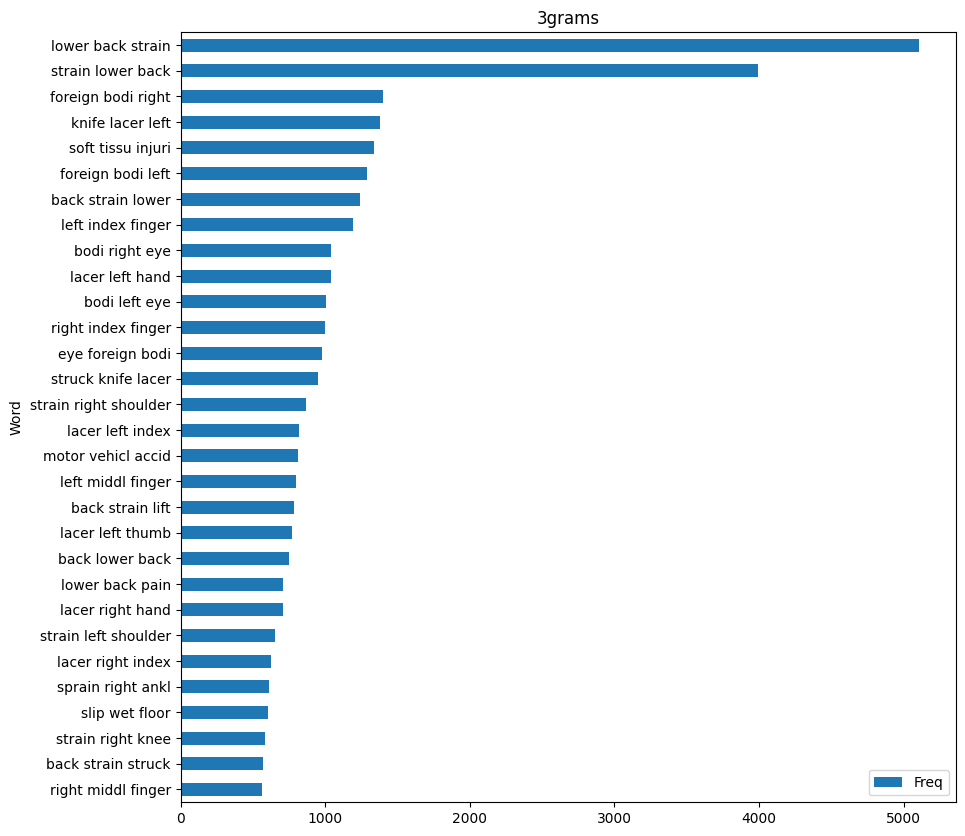

In [32]:
#Most common pairs of words that occur together in Claim Description

plt.figsize=((25,30))
dict_words_freq = nltk.FreqDist(nltk.ngrams(claims_tokens, 3))
dtf_bi = pd.DataFrame(dict_words_freq.most_common(), 
                      columns=["Word","Freq"])
dtf_bi["Word"] = dtf_bi["Word"].apply(lambda x: " ".join(
                   string for string in x) )
dtf_bi.set_index("Word").iloc[:30,:].sort_values(by="Freq").plot(kind="barh",figsize=(10,10))
plt.title('3grams')
                  
plt.show()


# Model

In [33]:
df


,ClaimNumber,DateTimeOfAccident,DateReported,Age,Gender,MaritalStatus,DependentChildren,DependentsOther,WeeklyWages,PartTimeFullTime,HoursWorkedPerWeek,DaysWorkedPerWeek,ClaimDescription,InitialIncurredCalimsCost,UltimateIncurredClaimCost,accident_report_delay_hours,accident_year,accident_month,accident_day,accident_hour,reported_year,reported_month,ClaimDescription_word_count,ClaimDescription_clean,ClaimDescription_tfidf_cluster,ClaimDescription_count_cluster,CD_right,CD_left,CD_strain,CD_back,CD_lacer,CD_lower,CD_finger,CD_lift,CD_hand,CD_struck,CD_shoulder,CD_slip,CD_fell,CD_eye,CD_knee,CD_injuri,CD_bruis,CD_foreign,CD_bodi,CD_cut,CD_wrist,CD_thumb,CD_neck,CD_ankl,...,CD_strain right,CD_right knee,CD_knife lacer,CD_strain left,CD_left shoulder,CD_right eye,CD_left eye,CD_middl finger,CD_soft tissu,CD_left thumb,CD_left knee,CD_left wrist,CD_right wrist,CD_bodi right,CD_bruis right,CD_tissu injuri,CD_strain back,CD_bodi left,CD_right arm,CD_left index,CD_injuri left,CD_bruis left,CD_back pain,CD_left ankl,CD_right foot,CD_right ankl,CD_struck knife,CD_strain lift,CD_injuri right,CD_shoulder strain,CD_lower back strain,CD_strain lower back,CD_foreign bodi right,CD_knife lacer left,CD_soft tissu injuri,CD_foreign bodi left,CD_back strain lower,CD_left index finger,CD_bodi right eye,CD_lacer left hand,CD_bodi left eye,CD_right index finger,CD_eye foreign bodi,CD_struck knife lacer,CD_strain right shoulder,CD_lacer left index,CD_motor vehicl accid,CD_left middl finger,CD_back strain lift,CD_lacer left thumb
0,WC8285054,2002-04-09 07:00:00+00:00,2002-07-05 00:00:00+00:00,48,M,M,0,0,500.00,F,38.00,5,LIFTING TYRE INJURY TO RIGHT ARM AND WRIST INJURY,1500,4748.20,2081.00,2002,4,9,7,5,7,49,lift tyre injuri right arm wrist injuri,23,28,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,WC6982224,1999-01-07 11:00:00+00:00,1999-01-20 00:00:00+00:00,43,F,M,0,0,509.34,F,37.50,5,STEPPED AROUND CRATES AND TRUCK TRAY FRACTURE ...,5500,6326.29,301.00,1999,1,7,11,20,1,58,step around crate truck tray fractur left forearm,23,24,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,WC5481426,1996-03-25 00:00:00+00:00,1996-04-14 00:00:00+00:00,30,M,U,0,0,709.10,F,38.00,5,CUT ON SHARP EDGE CUT LEFT THUMB,1700,2293.95,480.00,1996,3,25,0,14,4,32,cut sharp edg cut left thumb,11,3,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,WC9775968,2005-06-22 13:00:00+00:00,2005-07-22 00:00:00+00:00,41,M,S,0,0,555.46,F,38.00,5,DIGGING LOWER BACK LOWER BACK STRAIN,15000,17786.49,707.00,2005,6,22,13,22,7,36,dig lower back lower back strain,2,20,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,WC2634037,1990-08-29 08:00:00+00:00,1990-09-27 00:00:00+00:00,36,M,M,0,0,377.10,F,38.00,5,REACHING ABOVE SHOULDER LEVEL ACUTE MUSCLE STR...,2800,4014.00,688.00,1990,8,29,8,27,9,70,reach shoulder level acut muscl strain left si...,23,29,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53995,WC9370727,2004-08-21 18:00:00+00:00,2004-09-08 00:00:00+00:00,32,F,S,0,0,500.00,F,38.00,5,STRUCK KNIFE LACERATED LEFT MIDDLE FINGER LEFT...,1000,480.49,414.00,2004,8,21,18,8,9,51,stru